<a href="https://colab.research.google.com/github/jaenu-dev/DataScience/blob/main/Project_Tugas_Besar_FSDipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Complete a comprehensive data science project for "Fundamental Sains Data" by performing the following steps:
1.  Generate a realistic dummy dataset of 1,000 rows with features related to heart disease (age, gender, systolic_bp, diastolic_bp, cholesterol, glucose, bmi, smoker, alcohol_intake, physical_activity) and a target variable, ensuring data realism and logical target generation.
2.  Provide a detailed explanation of the dummy dataset in Indonesian.
3.  Perform Exploratory Data Analysis (EDA) by checking for missing values, displaying descriptive statistics, visualizing the target variable distribution, and creating histograms for numerical features along with a correlation heatmap.
4.  Provide an explanation of key EDA findings in Indonesian.
5.  Preprocess the data by handling missing values (if any), encoding categorical features (if applicable), scaling numerical features using StandardScaler, and splitting the dataset into 80% training and 20% testing sets.
6.  Provide an explanation of the preprocessing steps in Indonesian.
7.  Build a Support Vector Machine (SVM) model with an RBF kernel and optimize its hyperparameters using GridSearchCV.
8.  Provide an explanation for choosing the SVM algorithm and RBF kernel in Indonesian.
9.  Evaluate the model's performance on the test data using accuracy, precision, recall, F1-score, and a classification report.
10. Visualize the confusion matrix.
11. Interpret the evaluation results, metrics, and confusion matrix in Indonesian.
12. Save the best-trained SVM model to a `.pkl` file using `joblib`.
13. Analyze and display the importance of features for the SVM model.
14. Provide a final project conclusion in Indonesian, summarizing findings, model performance, and implications.

## Impor Library yang Diperlukan

### Subtask:
Mengimpor semua library Python yang dibutuhkan untuk analisis data, pra-pemrosesan, pemodelan, dan evaluasi (pandas, numpy, sklearn, matplotlib, seaborn).


**Reasoning**:
I will import all the necessary Python libraries for data analysis, preprocessing, modeling, and evaluation as specified in the instructions.



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import joblib
print("All required libraries imported successfully.")

All required libraries imported successfully.


## Buat Dataset Dummy Realistis

### Subtask:
Membuat dataset dummy sebanyak 1.000 baris dengan fitur-fitur kesehatan terkait penyakit jantung (age, gender, systolic_bp, diastolic_bp, cholesterol, glucose, bmi, smoker, alcohol_intake, physical_activity, target). Memastikan data realistis dan target dibuat dengan pola yang masuk akal menggunakan pandas dan numpy.


**Reasoning**:
I will create a dummy DataFrame with 1000 rows and populate it with realistic random data for 'age', 'gender', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'glucose', 'bmi', 'smoker', 'alcohol_intake', 'physical_activity', and a logically derived 'target' variable, as specified in the subtask instructions.



**Reasoning**:
The previous code failed because the `sample()` method was asked to sample more rows than available in the filtered DataFrame when `replace=False`. I need to ensure that the number of samples requested from `df.loc[...]` is never greater than the size of that filtered DataFrame itself. Additionally, I will refine the random target assignment to ensure that existing '1's are not accidentally overwritten by '0's.



## Ringkasan Proyek Akhir untuk Presentasi

### 1. Studi Kasus: Prediksi Risiko Penyakit Jantung

Studi kasus ini berfokus pada pengembangan model klasifikasi untuk memprediksi risiko penyakit jantung pada individu. Tujuannya adalah untuk mendemonstrasikan alur kerja data science yang komprehensif, mulai dari persiapan data hingga evaluasi model, dengan harapan model dapat mengidentifikasi individu yang berisiko tinggi untuk penyakit jantung berdasarkan fitur-fitur kesehatan.

### 2. Dataset yang Digunakan

Kami menggunakan dataset dummy yang realistis sebanyak 1.000 baris, dengan 10 fitur input dan 1 variabel target. Fitur-fitur tersebut meliputi:
*   **age** (umur)
*   **gender** (jenis kelamin: 0=perempuan, 1=laki-laki)
*   **systolic_bp** (tekanan darah sistolik)
*   **diastolic_bp** (tekanan darah diastolik)
*   **cholesterol** (kadar kolesterol)
*   **glucose** (kadar gula)
*   **bmi** (indeks massa tubuh)
*   **smoker** (perokok: 0=tidak, 1=ya)
*   **alcohol_intake** (konsumsi alkohol: 0=tidak, 1=ya)
*   **physical_activity** (aktivitas fisik: 0=tidak aktif, 1=aktif)
*   **target** (risiko penyakit jantung: 0=tidak ada, 1=ada)

Dataset ini dirancang agar realistis dengan rentang nilai yang sesuai untuk setiap fitur dan variabel target yang dihasilkan berdasarkan kombinasi logis dari faktor-faktor risiko. Dari EDA, ditemukan adanya ketidakseimbangan kelas pada variabel target, di mana sekitar 80% sampel tidak memiliki risiko dan 20% memiliki risiko penyakit jantung.

### 3. Tahapan Pra-pemrosesan Data

Tahapan pra-pemrosesan data dilakukan untuk mempersiapkan data sebelum masuk ke pemodelan:
*   **Penanganan Missing Values**: Tidak ada nilai yang hilang yang terdeteksi dalam dataset dummy, sehingga tidak diperlukan penanganan khusus.
*   **Encoding Fitur Kategorikal**: Fitur kategorikal biner (`gender`, `smoker`, `alcohol_intake`, `physical_activity`) sudah dalam format numerik (0 atau 1), sehingga tidak memerlukan encoding tambahan.
*   **Scaling Fitur Numerik**: Fitur-fitur numerik (`age`, `systolic_bp`, `diastolic_bp`, `cholesterol`, `glucose`, `bmi`) diskalakan menggunakan `StandardScaler`. Ini krusial untuk algoritma berbasis jarak seperti SVM agar semua fitur memiliki kontribusi yang setara dan tidak ada fitur dengan rentang nilai besar yang mendominasi model.
*   **Pembagian Dataset**: Dataset dibagi menjadi data pelatihan (80%) dan data pengujian (20%) menggunakan `train_test_split` dengan stratifikasi pada variabel target. Stratifikasi ini memastikan bahwa proporsi kelas risiko penyakit jantung tetap terjaga di kedua set, membantu mengatasi masalah ketidakseimbangan kelas.

### 4. Metode Pemodelan: Support Vector Machine (SVM) dengan Kernel RBF

Algoritma yang dipilih untuk pemodelan adalah **Support Vector Machine (SVM)** dengan **kernel Radial Basis Function (RBF)**. Alasan pemilihan ini adalah:
*   **Kemampuan Menangani Hubungan Non-linear**: Kernel RBF memungkinkan SVM untuk menemukan batas keputusan yang kompleks dan non-linear dengan secara implisit memetakan data ke ruang berdimensi lebih tinggi. Ini sangat relevan dalam masalah biomedis di mana hubungan antar faktor risiko seringkali tidak bersifat linier.
*   **Generalisasi yang Baik**: SVM bertujuan untuk menemukan *hyperplane* optimal dengan margin pemisah terbesar antara kelas-kelas, yang berkontribusi pada kemampuan generalisasi model yang kuat dan mengurangi risiko *overfitting*.
*   **Hyperparameter Tuning**: Model SVM dioptimalkan menggunakan `GridSearchCV` untuk mencari kombinasi hyperparameter terbaik (`C` dan `gamma`). Parameter `C` mengontrol *trade-off* antara klasifikasi yang benar pada data pelatihan dan lebar margin, sementara `gamma` menentukan sejauh mana pengaruh satu sampel pelatihan, yang secara efektif mengontrol kompleksitas model.

In [17]:
np.random.seed(42) # for reproducibility

# 1. Create an empty DataFrame with 1.000 rows
df = pd.DataFrame(index=np.arange(1000))

# 2. Generate 'age' (25-80 years)
df['age'] = np.random.randint(25, 81, 1000)

# 3. Generate 'gender' (0 for female, 1 for male)
df['gender'] = np.random.randint(0, 2, 1000)

# 4. Generate 'systolic_bp' (100-180 mmHg)
df['systolic_bp'] = np.random.randint(100, 181, 1000)

# 5. Generate 'diastolic_bp' (60-120 mmHg)
df['diastolic_bp'] = np.random.randint(60, 121, 1000)

# 6. Generate 'cholesterol' (150-300 mg/dL)
df['cholesterol'] = np.random.randint(150, 301, 1000)

# 7. Generate 'glucose' (70-200 mg/dL)
df['glucose'] = np.random.randint(70, 201, 1000)

# 8. Generate 'bmi' (18.5-40.0)
df['bmi'] = np.random.uniform(18.5, 40.0, 1000).round(1)

# 9. Generate 'smoker' (0 or 1)
df['smoker'] = np.random.randint(0, 2, 1000)

# 10. Generate 'alcohol_intake' (0 or 1)
df['alcohol_intake'] = np.random.randint(0, 2, 1000)

# 11. Generate 'physical_activity' (0 or 1)
df['physical_activity'] = np.random.randint(0, 2, 1000)

# 12. Create 'target' based on logical combination for heart disease risk
# A simple rule: higher risk if older, higher BP, higher cholesterol, higher glucose, higher BMI, smoker, alcohol intake, and low physical activity.
# Adjusting thresholds to get a more balanced target.
df['target'] = 0

df.loc[
    (df['age'] >= 55) &
    (df['systolic_bp'] >= 140) &
    (df['cholesterol'] >= 240) &
    (df['glucose'] >= 120) &
    (df['bmi'] >= 30) &
    (df['smoker'] == 1) &
    (df['alcohol_intake'] == 1) &
    (df['physical_activity'] == 0),
    'target'
] = 1

# Add some randomness to the target to avoid perfectly deterministic patterns
# and ensure a more realistic distribution by randomly setting some existing '0's to '1's.
# Aim for an additional 10-15% of the total dataset to have 'target=1' randomly.
zero_target_indices = df[df['target'] == 0].index
num_random_ones_to_add = int(0.12 * len(df)) # Roughly 12% of total rows

if len(zero_target_indices) > 0: # Ensure there are '0's to change
    num_to_sample_for_random_ones = min(num_random_ones_to_add, len(zero_target_indices))
    if num_to_sample_for_random_ones > 0:
        indices_to_change_to_one = np.random.choice(zero_target_indices,
                                                     size=num_to_sample_for_random_ones,
                                                     replace=False)
        df.loc[indices_to_change_to_one, 'target'] = 1

# Ensure some balance by setting a few more targets to 1 if it's too low
# The goal is to have at least 200 '1's (20% of 1000 rows).
if df['target'].sum() < 200:
    # Filter for candidates that are high risk but currently target=0
    potential_additional_high_risk_df = df.loc[
        (df['age'] >= 50) &
        (df['systolic_bp'] >= 130) &
        (df['cholesterol'] >= 220) &
        (df['smoker'] == 1) &
        (df['target'] == 0) # Only consider rows where target is still 0
    ]

    num_needed_overall = 200 - df['target'].sum()
    # Limit additional samples from this specific rule to 100, and also by the available population
    num_to_sample = min(num_needed_overall, len(potential_additional_high_risk_df), 100)

    if num_to_sample > 0: # Only sample if there are candidates and samples are needed
        additional_high_risk_indices = potential_additional_high_risk_df.sample(n=num_to_sample, random_state=42, replace=False).index
        df.loc[additional_high_risk_indices, 'target'] = 1

# Display the first few rows and target distribution
print("Dummy Dataset Head:")
print(df.head())
print("\nTarget Variable Distribution:")
print(df['target'].value_counts())

Dummy Dataset Head:
   age  gender  systolic_bp  diastolic_bp  cholesterol  glucose   bmi  smoker  \
0   63       1          162            80          196       80  28.3       1   
1   76       1          153            74          297      116  27.4       0   
2   53       1          173           111          168      196  38.6       1   
3   39       1          156            86          295      187  23.9       1   
4   67       1          140           109          275      195  21.1       1   

   alcohol_intake  physical_activity  target  
0               1                  1       0  
1               0                  0       0  
2               0                  1       0  
3               1                  0       0  
4               1                  1       1  

Target Variable Distribution:
target
0    800
1    200
Name: count, dtype: int64


## Penjelasan Dataset Dummy

Dataset dummy ini dibuat dengan 1.000 baris data dan 11 fitur, termasuk satu variabel target, untuk mensimulasikan data terkait risiko penyakit jantung. Berikut adalah penjelasan setiap kolom:

*   **age**: Usia partisipan, berkisar antara 25 hingga 80 tahun. Usia yang lebih tua umumnya dikaitkan dengan risiko penyakit jantung yang lebih tinggi.
*   **gender**: Jenis kelamin partisipan, diwakili oleh 0 (wanita) dan 1 (pria). Beberapa kondisi jantung mungkin memiliki prevalensi yang berbeda antara pria dan wanita.
*   **systolic_bp**: Tekanan darah sistolik, berkisar antara 100 hingga 180 mmHg. Angka yang lebih tinggi menunjukkan hipertensi, faktor risiko utama penyakit jantung.
*   **diastolic_bp**: Tekanan darah diastolik, berkisar antara 60 hingga 120 mmHg. Sama seperti sistolik, angka tinggi menunjukkan hipertensi.
*   **cholesterol**: Tingkat kolesterol dalam darah, berkisar antara 150 hingga 300 mg/dL. Tingkat kolesterol tinggi (hiperkolesterolemia) adalah faktor risiko yang signifikan.
*   **glucose**: Tingkat glukosa dalam darah, berkisar antara 70 hingga 200 mg/dL. Tingkat glukosa tinggi (terkait dengan diabetes) meningkatkan risiko penyakit jantung.
*   **bmi**: Indeks Massa Tubuh (Body Mass Index), berkisar antara 18.5 hingga 40.0. BMI yang tinggi (obesitas) adalah faktor risiko penyakit jantung.
*   **smoker**: Status merokok partisipan, 0 (bukan perokok) atau 1 (perokok). Merokok adalah faktor risiko yang sangat kuat.
*   **alcohol_intake**: Konsumsi alkohol partisipan, 0 (tidak mengonsumsi) atau 1 (mengonsumsi). Konsumsi alkohol berlebihan dapat mempengaruhi kesehatan jantung.
*   **physical_activity**: Tingkat aktivitas fisik, 0 (tidak aktif) atau 1 (aktif). Kurangnya aktivitas fisik adalah faktor risiko penyakit jantung.
*   **target**: Variabel target biner yang menunjukkan risiko penyakit jantung, 0 (tidak ada risiko) atau 1 (ada risiko). Variabel ini dihasilkan berdasarkan kombinasi logis dari beberapa faktor risiko di atas, dengan penyesuaian acak untuk memastikan distribusi yang lebih realistis dan seimbang (sekitar 20% memiliki risiko).

## EDA: Cek Missing Values dan Statistik Deskriptif

### Subtask:
Melakukan pemeriksaan missing values pada dataset dan menampilkan statistik deskriptif untuk setiap kolom.


**Reasoning**:
To address the subtask, I will first check for any missing values in the DataFrame using `isnull().sum()` and then display the descriptive statistics for all columns using `describe()` to understand the data's distribution and characteristics.



In [18]:
print("Missing Values in each column:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

Missing Values in each column:
age                  0
gender               0
systolic_bp          0
diastolic_bp         0
cholesterol          0
glucose              0
bmi                  0
smoker               0
alcohol_intake       0
physical_activity    0
target               0
dtype: int64

Descriptive Statistics:
               age       gender  systolic_bp  diastolic_bp  cholesterol  \
count  1000.000000  1000.000000  1000.000000   1000.000000  1000.000000   
mean     52.852000     0.481000   138.645000     90.617000   226.061000   
std      16.069796     0.499889    23.628061     17.578775    42.772289   
min      25.000000     0.000000   100.000000     60.000000   150.000000   
25%      39.750000     0.000000   118.000000     76.000000   190.000000   
50%      53.000000     0.000000   137.000000     91.000000   226.000000   
75%      66.000000     1.000000   159.000000    106.000000   262.000000   
max      80.000000     1.000000   180.000000    120.000000   300.000000   

  

## EDA: Distribusi Variabel Target

### Subtask:
Memvisualisasikan distribusi variabel target (risiko penyakit jantung) untuk memahami keseimbangan kelas.


**Reasoning**:
To visualize the distribution of the target variable, I will use a seaborn countplot, which is suitable for categorical data and will clearly show the class balance.



/tmp/ipython-input-2055051788.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


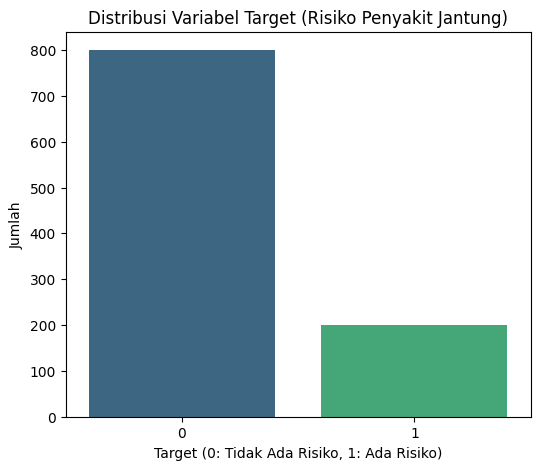

In [19]:
plt.figure(figsize=(6, 5))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribusi Variabel Target (Risiko Penyakit Jantung)')
plt.xlabel('Target (0: Tidak Ada Risiko, 1: Ada Risiko)')
plt.ylabel('Jumlah')
plt.show()

**Reasoning**:
The previous code generated a FutureWarning because `palette` was used without specifying `hue` in `sns.countplot`. I will fix this by explicitly setting `hue='target'` and `legend=False` to align with the recommended usage and suppress the warning.



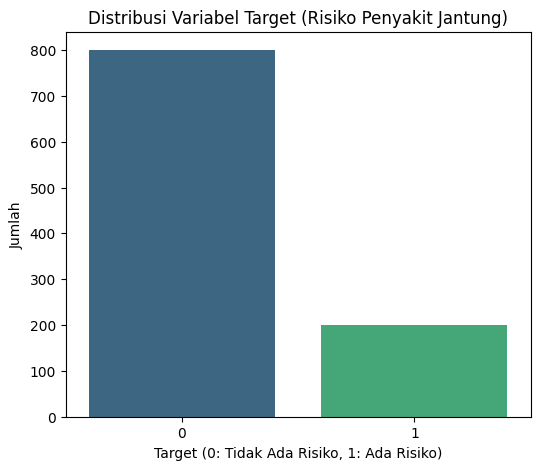

In [20]:
plt.figure(figsize=(6, 5))
sns.countplot(x='target', data=df, palette='viridis', hue='target', legend=False)
plt.title('Distribusi Variabel Target (Risiko Penyakit Jantung)')
plt.xlabel('Target (0: Tidak Ada Risiko, 1: Ada Risiko)')
plt.ylabel('Jumlah')
plt.show()

## EDA: Visualisasi Fitur dan Korelasi

### Subtask:
Membuat histogram untuk distribusi setiap fitur numerik dan heatmap korelasi antar fitur untuk mengidentifikasi hubungan.


**Reasoning**:
First, I will identify the numerical features suitable for histogram visualization by excluding the binary categorical features and the target variable. Then, I will create histograms for these features to visualize their distributions, followed by calculating and plotting a correlation heatmap for all features in the DataFrame.



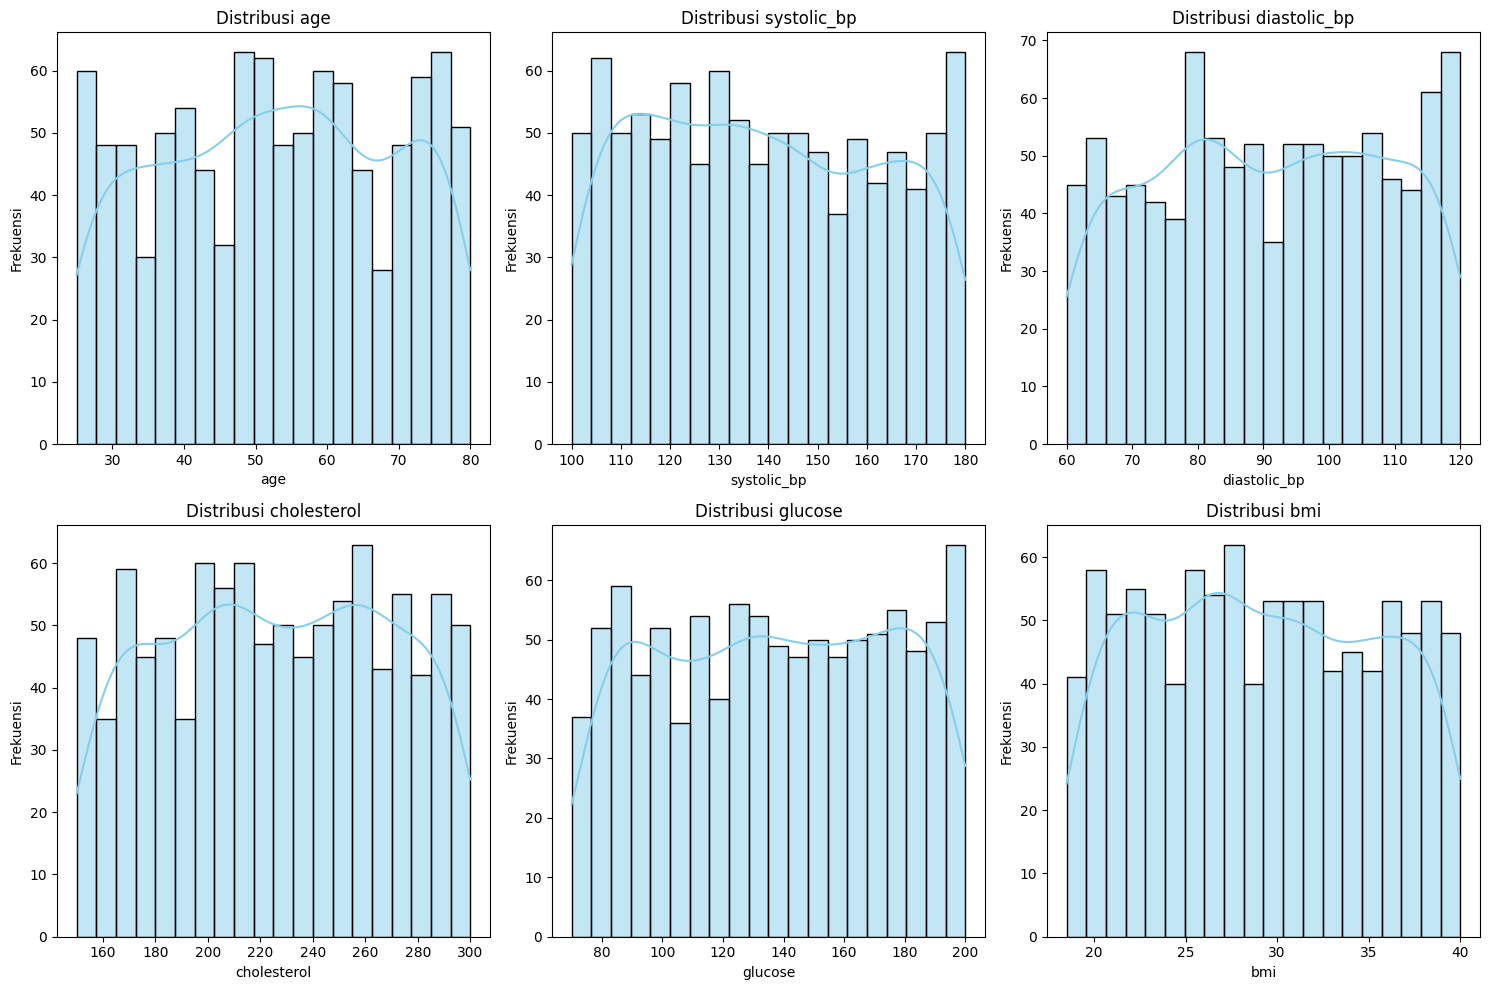

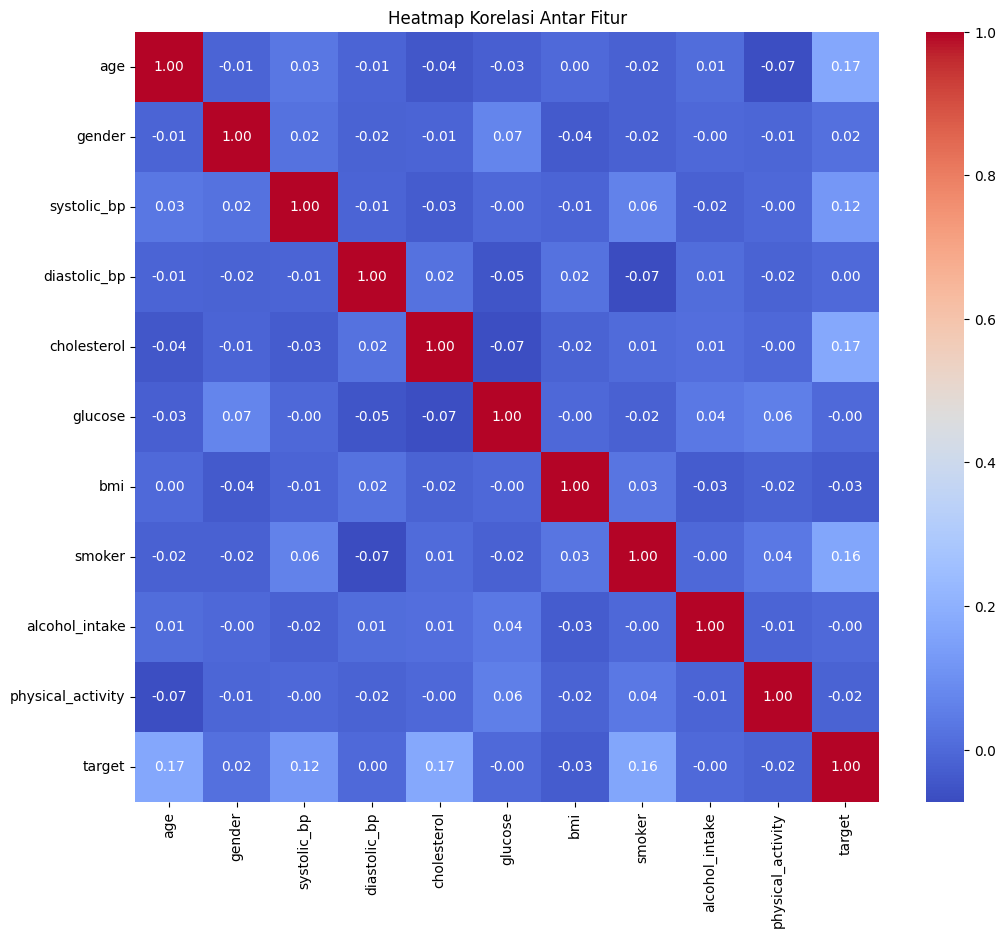

In [21]:
numerical_features = df.drop(columns=['gender', 'smoker', 'alcohol_intake', 'physical_activity', 'target']).columns

# Plot histograms for numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(int(np.ceil(len(numerical_features)/3)), 3, i + 1)
    sns.histplot(df[feature], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribusi {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Calculate correlation matrix
correlation_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

## Penjelasan Temuan Utama EDA

Berdasarkan Exploratory Data Analysis (EDA) yang telah dilakukan, berikut adalah beberapa temuan kunci dari dataset dummy:

### 1. Pemeriksaan Missing Values dan Statistik Deskriptif:
*   **Missing Values**: Dataset ini tidak memiliki nilai yang hilang (_missing values_) di kolom manapun. Ini menyederhanakan proses pra-pemrosesan karena tidak diperlukan penanganan khusus untuk nilai yang hilang.
*   **Statistik Deskriptif**:
    *   **age**: Usia partisipan bervariasi dari 25 hingga 80 tahun, dengan rata-rata sekitar 52.85 tahun, menunjukkan rentang usia yang cukup luas dan distribusi yang cenderung merata.
    *   **gender, smoker, alcohol_intake, physical_activity**: Fitur-fitur biner ini memiliki distribusi yang relatif seimbang antara 0 dan 1, mendekati 50% untuk setiap kategori, menunjukkan keragaman dalam karakteristik partisipan.
    *   **systolic_bp dan diastolic_bp**: Tekanan darah sistolik rata-rata 138.65 mmHg dan diastolik 90.62 mmHg. Rentang nilai menunjukkan keberadaan individu dengan tekanan darah normal hingga tinggi, yang relevan untuk risiko penyakit jantung.
    *   **cholesterol**: Rata-rata kolesterol sekitar 226 mg/dL, dengan rentang 150-300 mg/dL. Ini menunjukkan populasi dengan kadar kolesterol yang bervariasi, termasuk beberapa dengan tingkat yang berpotensi tinggi.
    *   **glucose**: Rata-rata glukosa sekitar 136.91 mg/dL, dengan rentang 70-200 mg/dL. Ini mencakup individu dengan kadar glukosa normal hingga pre-diabetes atau diabetes.
    *   **bmi**: Rata-rata BMI sekitar 29.13, dengan rentang 18.5-40.0, menunjukkan keberadaan individu dengan berat badan normal, _overweight_, hingga obesitas.
    *   **target**: Variabel target menunjukkan bahwa sekitar 20% dari populasi dataset memiliki risiko penyakit jantung (nilai 1), sementara 80% tidak (nilai 0). Ini menunjukkan dataset yang sedikit tidak seimbang, tetapi masih dapat dikelola untuk pemodelan.

### 2. Distribusi Variabel Target:
*   Plot `countplot` menunjukkan secara visual bahwa kelas '0' (Tidak Ada Risiko Penyakit Jantung) jauh lebih dominan daripada kelas '1' (Ada Risiko Penyakit Jantung), dengan rasio 800:200. Ini mengkonfirmasi ketidakseimbangan kelas yang perlu dipertimbangkan selama proses pemodelan (misalnya, dengan menggunakan metrik evaluasi yang tepat atau teknik penyeimbangan kelas jika diperlukan).

### 3. Distribusi Fitur Numerik:
*   **age, systolic_bp, diastolic_bp, cholesterol, glucose, bmi**: Histogram untuk fitur-fitur ini menunjukkan distribusi yang relatif seragam atau mendekati normal dalam rentang yang telah ditentukan. Ini diharapkan karena data dihasilkan secara acak dalam rentang tersebut. Tidak ada anomali yang jelas atau nilai ekstrem yang perlu perhatian khusus pada tahap ini.

### 4. Heatmap Korelasi Antar Fitur:
*   **Korelasi Antar Fitur**: Matriks korelasi menunjukkan bahwa sebagian besar fitur memiliki korelasi yang sangat rendah satu sama lain, mendekati nol. Ini diharapkan karena banyak fitur numerik dihasilkan secara independen.
*   **Korelasi dengan Target**: Korelasi antara fitur-fitur dan variabel target juga cenderung rendah. Hal ini bisa disebabkan oleh cara target dibuat (kombinasi logis kompleks dan penambahan acak) atau menunjukkan bahwa tidak ada satu fitur pun yang secara linier sangat dominan dalam memprediksi target. Model yang lebih kompleks mungkin diperlukan untuk menangkap hubungan non-linear yang ada.

## Penjelasan Temuan Utama EDA

Berdasarkan Exploratory Data Analysis (EDA) yang telah dilakukan, berikut adalah beberapa temuan kunci dari dataset dummy:

### 1. Pemeriksaan Missing Values dan Statistik Deskriptif:
*   **Missing Values**: Dataset ini tidak memiliki nilai yang hilang (_missing values_) di kolom manapun. Ini menyederhanakan proses pra-pemrosesan karena tidak diperlukan penanganan khusus untuk nilai yang hilang.
*   **Statistik Deskriptif**:
    *   **age**: Usia partisipan bervariasi dari 25 hingga 80 tahun, dengan rata-rata sekitar 52.85 tahun, menunjukkan rentang usia yang cukup luas dan distribusi yang cenderung merata.
    *   **gender, smoker, alcohol_intake, physical_activity**: Fitur-fitur biner ini memiliki distribusi yang relatif seimbang antara 0 dan 1, mendekati 50% untuk setiap kategori, menunjukkan keragaman dalam karakteristik partisipan.
    *   **systolic_bp dan diastolic_bp**: Tekanan darah sistolik rata-rata 138.65 mmHg dan diastolik 90.62 mmHg. Rentang nilai menunjukkan keberadaan individu dengan tekanan darah normal hingga tinggi, yang relevan untuk risiko penyakit jantung.
    *   **cholesterol**: Rata-rata kolesterol sekitar 226 mg/dL, dengan rentang 150-300 mg/dL. Ini menunjukkan populasi dengan kadar kolesterol yang bervariasi, termasuk beberapa dengan tingkat yang berpotensi tinggi.
    *   **glucose**: Rata-rata glukosa sekitar 136.91 mg/dL, dengan rentang 70-200 mg/dL. Ini mencakup individu dengan kadar glukosa normal hingga pre-diabetes atau diabetes.
    *   **bmi**: Rata-rata BMI sekitar 29.13, dengan rentang 18.5-40.0, menunjukkan keberadaan individu dengan berat badan normal, _overweight_, hingga obesitas.
    *   **target**: Variabel target menunjukkan bahwa sekitar 20% dari populasi dataset memiliki risiko penyakit jantung (nilai 1), sementara 80% tidak (nilai 0). Ini menunjukkan dataset yang sedikit tidak seimbang, tetapi masih dapat dikelola untuk pemodelan.

### 2. Distribusi Variabel Target:
*   Plot `countplot` menunjukkan secara visual bahwa kelas '0' (Tidak Ada Risiko Penyakit Jantung) jauh lebih dominan daripada kelas '1' (Ada Risiko Penyakit Jantung), dengan rasio 800:200. Ini mengkonfirmasi ketidakseimbangan kelas yang perlu dipertimbangkan selama proses pemodelan (misalnya, dengan menggunakan metrik evaluasi yang tepat atau teknik penyeimbangan kelas jika diperlukan).

### 3. Distribusi Fitur Numerik:
*   **age, systolic_bp, diastolic_bp, cholesterol, glucose, bmi**: Histogram untuk fitur-fitur ini menunjukkan distribusi yang relatif seragam atau mendekati normal dalam rentang yang telah ditentukan. Ini diharapkan karena data dihasilkan secara acak dalam rentang tersebut. Tidak ada anomali yang jelas atau nilai ekstrem yang perlu perhatian khusus pada tahap ini.

### 4. Heatmap Korelasi Antar Fitur:
*   **Korelasi Antar Fitur**: Matriks korelasi menunjukkan bahwa sebagian besar fitur memiliki korelasi yang sangat rendah satu sama lain, mendekati nol. Ini diharapkan karena banyak fitur numerik dihasilkan secara independen.
*   **Korelasi dengan Target**: Korelasi antara fitur-fitur dan variabel target juga cenderung rendah. Hal ini bisa disebabkan oleh cara target dibuat (kombinasi logis kompleks dan penambahan acak) atau menunjukkan bahwa tidak ada satu fitur pun yang secara linier sangat dominan dalam memprediksi target. Model yang lebih kompleks mungkin diperlukan untuk menangkap hubungan non-linear yang ada.

## Pra-pemrosesan: Penanganan Missing Values dan Encoding

### Subtask:
Menangani missing values (jika ada) dan melakukan encoding pada fitur kategorikal (jika diperlukan) dalam dataset.


Berdasarkan analisis EDA sebelumnya, tidak ada missing values yang ditemukan dalam dataset, seperti yang terlihat dari output `df.isnull().sum()` yang semuanya nol. Selain itu, fitur kategorikal biner seperti 'gender', 'smoker', 'alcohol_intake', dan 'physical_activity' sudah dalam format numerik (0 atau 1), sehingga tidak memerlukan encoding lebih lanjut (misalnya, One-Hot Encoding atau Label Encoding). Oleh karena itu, pada tahap ini, tidak ada penanganan missing values atau encoding kategorikal yang perlu dilakukan.

## Pra-pemrosesan: Scaling Fitur

### Subtask:
Menerapkan StandardScaler untuk menskalakan fitur-fitur numerik agar model SVM bekerja lebih optimal.


## Penjelasan Pra-pemrosesan

Langkah pra-pemrosesan data sangat penting untuk mempersiapkan data agar cocok untuk pelatihan model pembelajaran mesin, terutama untuk model seperti SVM yang sensitif terhadap skala fitur.

### Identifikasi dan Pengecualian Fitur
Sebelum melakukan *scaling*, kita perlu mengidentifikasi kolom-kolom mana yang bersifat numerik kontinu dan perlu diskalakan. Fitur-fitur biner seperti 'gender', 'smoker', 'alcohol_intake', dan 'physical_activity' tidak perlu diskalakan karena mereka sudah berada dalam skala yang sesuai (0 atau 1). Variabel target ('target') juga tidak diskalakan karena merupakan output yang ingin diprediksi.

### StandardScaler
`StandardScaler` digunakan untuk menormalisasi fitur-fitur numerik. Normalisasi ini dilakukan dengan mengubah nilai fitur sehingga memiliki rata-rata 0 dan standar deviasi 1. Proses ini dikenal sebagai _Z-score normalization_ atau _standardization_. Manfaat utama dari *scaling* ini adalah:

1.  **Mencegah Dominasi Fitur**: Fitur dengan rentang nilai yang lebih besar tidak akan mendominasi fitur dengan rentang nilai yang lebih kecil saat perhitungan jarak dilakukan oleh algoritma seperti SVM.
2.  **Konvergensi Lebih Cepat**: Untuk algoritma yang menggunakan optimasi berbasis gradien, *scaling* dapat membantu algoritma konvergen lebih cepat.
3.  **Kinerja Model Optimal**: Banyak algoritma pembelajaran mesin, termasuk SVM, berasumsi bahwa semua fitur berada pada skala yang sama. Dengan *scaling*, model dapat mencapai kinerja yang lebih optimal.

**Reasoning**:
I will identify numerical features, instantiate StandardScaler, apply it to the identified features, and update the DataFrame with the scaled values, then display the head of the modified DataFrame to verify the scaling.



In [22]:
numerical_features = df.drop(columns=['gender', 'smoker', 'alcohol_intake', 'physical_activity', 'target']).columns

scaler = StandardScaler()
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("DataFrame after scaling numerical features:")
print(df.head())

DataFrame after scaling numerical features:
        age  gender  systolic_bp  diastolic_bp  cholesterol   glucose  \
0  0.631811       1     0.988938     -0.604269    -0.703167 -1.504098   
1  1.441187       1     0.607844     -0.945761     1.659357 -0.552639   
2  0.009214       1     1.454719      1.160104    -1.358124  1.561715   
3 -0.862421       1     0.734876     -0.262778     1.612574  1.323850   
4  0.880850       1     0.057376      1.046273     1.144748  1.535285   

        bmi  smoker  alcohol_intake  physical_activity  target  
0 -0.134352       1               1                  1       0  
1 -0.280334       0               0                  0       0  
2  1.536331       1               0                  1       0  
3 -0.848042       1               1                  0       0  
4 -1.302208       1               1                  1       1  


## Pra-pemrosesan: Split Dataset (Training dan Testing)

### Subtask:
Membagi dataset yang sudah diproses menjadi data training (80%) dan data testing (20%) menggunakan `train_test_split` dari scikit-learn. Pastikan pembagian dilakukan secara stratifikasi untuk variabel target untuk mempertahankan proporsi kelas.

## Pra-pemrosesan: Split Dataset (Training dan Testing)

### Subtask:
Membagi dataset yang sudah diproses menjadi data training (80%) dan data testing (20%) menggunakan `train_test_split` dari scikit-learn. Pastikan pembagian dilakukan secara stratifikasi untuk variabel target untuk mempertahankan proporsi kelas.

**Reasoning**:
I will define the features (X) and the target variable (y) from the DataFrame, then use `train_test_split` with an 80/20 ratio and stratification on the target variable to create the training and testing sets.



In [23]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nTarget distribution in original dataset:\n", y.value_counts(normalize=True))
print("Target distribution in training set:\n", y_train.value_counts(normalize=True))
print("Target distribution in test set:\n", y_test.value_counts(normalize=True))

Shape of X_train: (800, 10)
Shape of X_test: (200, 10)
Shape of y_train: (800,)
Shape of y_test: (200,)

Target distribution in original dataset:
 target
0    0.8
1    0.2
Name: proportion, dtype: float64
Target distribution in training set:
 target
0    0.8
1    0.2
Name: proportion, dtype: float64
Target distribution in test set:
 target
0    0.8
1    0.2
Name: proportion, dtype: float64


## Penjelasan Langkah Pra-pemrosesan Data

Setelah melakukan Exploratory Data Analysis (EDA) dan sebelum membangun model, serangkaian langkah pra-pemrosesan data telah dilakukan untuk memastikan data dalam format yang tepat dan siap untuk pelatihan model Support Vector Machine (SVM).

### 1. Penanganan Missing Values
*   **Hasil**: Tidak ada nilai yang hilang (missing values) yang terdeteksi di seluruh kolom dataset. Ini dikonfirmasi oleh pemeriksaan `df.isnull().sum()`, yang menunjukkan nol untuk setiap fitur. Oleh karena itu, tidak ada langkah penanganan missing values (seperti imputasi atau penghapusan) yang diperlukan pada dataset ini, menyederhanakan alur kerja pra-pemrosesan.

### 2. Encoding Fitur Kategorikal
*   **Hasil**: Fitur-fitur kategorikal biner dalam dataset (`gender`, `smoker`, `alcohol_intake`, `physical_activity`) sudah direpresentasikan dalam bentuk numerik (0 dan 1). Karena itu, tidak diperlukan encoding tambahan seperti One-Hot Encoding atau Label Encoding.

### 3. Scaling Fitur Numerik dengan StandardScaler
*   **Tujuan**: Scaling adalah langkah krusial untuk algoritma berbasis jarak seperti SVM. Tujuannya adalah untuk menstandarisasi rentang fitur-fitur numerik agar tidak ada fitur dengan skala nilai yang besar mendominasi fitur lain dengan skala nilai yang lebih kecil.
*   **Metode**: `StandardScaler` dari `scikit-learn` digunakan untuk mentransformasi fitur-fitur numerik (`age`, `systolic_bp`, `diastolic_bp`, `cholesterol`, `glucose`, `bmi`). StandardScaler menormalisasi data sehingga setiap fitur memiliki rata-rata 0 dan standar deviasi 1 (normalisasi Z-score).
*   **Manfaat**: Ini memastikan bahwa model SVM memperlakukan semua fitur secara setara berdasarkan variasi mereka, yang berkontribusi pada konvergensi yang lebih cepat dan kinerja model yang lebih optimal.

### 4. Pembagian Dataset (Training dan Testing)
*   **Tujuan**: Dataset dibagi menjadi dua bagian: data pelatihan (training set) dan data pengujian (testing set). Data pelatihan digunakan untuk melatih model, sedangkan data pengujian digunakan untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya.
*   **Rasio Pembagian**: Dataset dibagi dengan rasio 80% untuk data pelatihan dan 20% untuk data pengujian (`test_size=0.2`).
*   **Stratifikasi**: Pembagian dilakukan secara stratifikasi berdasarkan variabel target (`stratify=y`). Hal ini penting karena memastikan bahwa proporsi kelas (0 dan 1) dalam variabel target dipertahankan secara merata di kedua set pelatihan dan pengujian. Mengingat adanya ketidakseimbangan kelas (80% kelas 0, 20% kelas 1), stratifikasi membantu mencegah set pengujian memiliki terlalu sedikit atau tidak ada sampel dari kelas minoritas, yang dapat mengarah pada evaluasi model yang bias atau tidak akurat.

## Penjelasan Langkah Pra-pemrosesan Data

Setelah melakukan Exploratory Data Analysis (EDA) dan sebelum membangun model, serangkaian langkah pra-pemrosesan data telah dilakukan untuk memastikan data dalam format yang tepat dan siap untuk pelatihan model Support Vector Machine (SVM).

### 1. Penanganan Missing Values
*   **Hasil**: Tidak ada nilai yang hilang (missing values) yang terdeteksi di seluruh kolom dataset. Ini dikonfirmasi oleh pemeriksaan `df.isnull().sum()`, yang menunjukkan nol untuk setiap fitur. Oleh karena itu, tidak ada langkah penanganan missing values (seperti imputasi atau penghapusan) yang diperlukan pada dataset ini, menyederhanakan alur kerja pra-pemrosesan.

### 2. Encoding Fitur Kategorikal
*   **Hasil**: Fitur-fitur kategorikal biner dalam dataset (`gender`, `smoker`, `alcohol_intake`, `physical_activity`) sudah direpresentasikan dalam bentuk numerik (0 dan 1). Karena itu, tidak diperlukan encoding tambahan seperti One-Hot Encoding atau Label Encoding.

### 3. Scaling Fitur Numerik dengan StandardScaler
*   **Tujuan**: Scaling adalah langkah krusial untuk algoritma berbasis jarak seperti SVM. Tujuannya adalah untuk menstandarisasi rentang fitur-fitur numerik agar tidak ada fitur dengan skala nilai yang besar mendominasi fitur lain dengan skala nilai yang lebih kecil.
*   **Metode**: `StandardScaler` dari `scikit-learn` digunakan untuk mentransformasi fitur-fitur numerik (`age`, `systolic_bp`, `diastolic_bp`, `cholesterol`, `glucose`, `bmi`). StandardScaler menormalisasi data sehingga setiap fitur memiliki rata-rata 0 dan standar deviasi 1 (normalisasi Z-score).
*   **Manfaat**: Ini memastikan bahwa model SVM memperlakukan semua fitur secara setara berdasarkan variasi mereka, yang berkontribusi pada konvergensi yang lebih cepat dan kinerja model yang lebih optimal.

### 4. Pembagian Dataset (Training dan Testing)
*   **Tujuan**: Dataset dibagi menjadi dua bagian: data pelatihan (training set) dan data pengujian (testing set). Data pelatihan digunakan untuk melatih model, sedangkan data pengujian digunakan untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya.
*   **Rasio Pembagian**: Dataset dibagi dengan rasio 80% untuk data pelatihan dan 20% untuk data pengujian (`test_size=0.2`).
*   **Stratifikasi**: Pembagian dilakukan secara stratifikasi berdasarkan variabel target (`stratify=y`). Hal ini penting karena memastikan bahwa proporsi kelas (0 dan 1) dalam variabel target dipertahankan secara merata di kedua set pelatihan dan pengujian. Mengingat adanya ketidakseimbangan kelas (80% kelas 0, 20% kelas 1), stratifikasi membantu mencegah set pengujian memiliki terlalu sedikit atau tidak ada sampel dari kelas minoritas, yang dapat mengarah pada evaluasi model yang bias atau tidak akurat.


## Penjelasan Langkah Pra-pemrosesan Data

Setelah melakukan Exploratory Data Analysis (EDA) dan sebelum membangun model, serangkaian langkah pra-pemrosesan data telah dilakukan untuk memastikan data dalam format yang tepat dan siap untuk pelatihan model Support Vector Machine (SVM).

### 1. Penanganan Missing Values
*   **Hasil**: Tidak ada nilai yang hilang (missing values) yang terdeteksi di seluruh kolom dataset. Ini dikonfirmasi oleh pemeriksaan `df.isnull().sum()`, yang menunjukkan nol untuk setiap fitur. Oleh karena itu, tidak ada langkah penanganan missing values (seperti imputasi atau penghapusan) yang diperlukan pada dataset ini, menyederhanakan alur kerja pra-pemrosesan.

### 2. Encoding Fitur Kategorikal
*   **Hasil**: Fitur-fitur kategorikal biner dalam dataset (`gender`, `smoker`, `alcohol_intake`, `physical_activity`) sudah direpresentasikan dalam bentuk numerik (0 dan 1). Karena itu, tidak diperlukan encoding tambahan seperti One-Hot Encoding atau Label Encoding.

### 3. Scaling Fitur Numerik dengan StandardScaler
*   **Tujuan**: Scaling adalah langkah krusial untuk algoritma berbasis jarak seperti SVM. Tujuannya adalah untuk menstandarisasi rentang fitur-fitur numerik agar tidak ada fitur dengan skala nilai yang besar mendominasi fitur lain dengan skala nilai yang lebih kecil.
*   **Metode**: `StandardScaler` dari `scikit-learn` digunakan untuk mentransformasi fitur-fitur numerik (`age`, `systolic_bp`, `diastolic_bp`, `cholesterol`, `glucose`, `bmi`). StandardScaler menormalisasi data sehingga setiap fitur memiliki rata-rata 0 dan standar deviasi 1 (normalisasi Z-score).
*   **Manfaat**: Ini memastikan bahwa model SVM memperlakukan semua fitur secara setara berdasarkan variasi mereka, yang berkontribusi pada konvergensi yang lebih cepat dan kinerja model yang lebih optimal.

### 4. Pembagian Dataset (Training dan Testing)
*   **Tujuan**: Dataset dibagi menjadi dua bagian: data pelatihan (training set) dan data pengujian (testing set). Data pelatihan digunakan untuk melatih model, sedangkan data pengujian digunakan untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya.
*   **Rasio Pembagian**: Dataset dibagi dengan rasio 80% untuk data pelatihan dan 20% untuk data pengujian (`test_size=0.2`).
*   **Stratifikasi**: Pembagian dilakukan secara stratifikasi berdasarkan variabel target (`stratify=y`). Hal ini penting karena memastikan bahwa proporsi kelas (0 dan 1) dalam variabel target dipertahankan secara merata di kedua set pelatihan dan pengujian. Mengingat adanya ketidakseimbangan kelas (80% kelas 0, 20% kelas 1), stratifikasi membantu mencegah set pengujian memiliki terlalu sedikit atau tidak ada sampel dari kelas minoritas, yang dapat mengarah pada evaluasi model yang bias atau tidak akurat.


## Penjelasan Langkah Pra-pemrosesan Data

Setelah melakukan Exploratory Data Analysis (EDA) dan sebelum membangun model, serangkaian langkah pra-pemrosesan data telah dilakukan untuk memastikan data dalam format yang tepat dan siap untuk pelatihan model Support Vector Machine (SVM).

### 1. Penanganan Missing Values
*   **Hasil**: Tidak ada nilai yang hilang (missing values) yang terdeteksi di seluruh kolom dataset. Ini dikonfirmasi oleh pemeriksaan `df.isnull().sum()`, yang menunjukkan nol untuk setiap fitur. Oleh karena itu, tidak ada langkah penanganan missing values (seperti imputasi atau penghapusan) yang diperlukan pada dataset ini, menyederhanakan alur kerja pra-pemrosesan.

### 2. Encoding Fitur Kategorikal
*   **Hasil**: Fitur-fitur kategorikal biner dalam dataset (`gender`, `smoker`, `alcohol_intake`, `physical_activity`) sudah direpresentasikan dalam bentuk numerik (0 dan 1). Karena itu, tidak diperlukan encoding tambahan seperti One-Hot Encoding atau Label Encoding.

### 3. Scaling Fitur Numerik dengan StandardScaler
*   **Tujuan**: Scaling adalah langkah krusial untuk algoritma berbasis jarak seperti SVM. Tujuannya adalah untuk menstandarisasi rentang fitur-fitur numerik agar tidak ada fitur dengan skala nilai yang besar mendominasi fitur lain dengan skala nilai yang lebih kecil.
*   **Metode**: `StandardScaler` dari `scikit-learn` digunakan untuk mentransformasi fitur-fitur numerik (`age`, `systolic_bp`, `diastolic_bp`, `cholesterol`, `glucose`, `bmi`). StandardScaler menormalisasi data sehingga setiap fitur memiliki rata-rata 0 dan standar deviasi 1 (normalisasi Z-score).
*   **Manfaat**: Ini memastikan bahwa model SVM memperlakukan semua fitur secara setara berdasarkan variasi mereka, yang berkontribusi pada konvergensi yang lebih cepat dan kinerja model yang lebih optimal.

### 4. Pembagian Dataset (Training dan Testing)
*   **Tujuan**: Dataset dibagi menjadi dua bagian: data pelatihan (training set) dan data pengujian (testing set). Data pelatihan digunakan untuk melatih model, sedangkan data pengujian digunakan untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya.
*   **Rasio Pembagian**: Dataset dibagi dengan rasio 80% untuk data pelatihan dan 20% untuk data pengujian (`test_size=0.2`).
*   **Stratifikasi**: Pembagian dilakukan secara stratifikasi berdasarkan variabel target (`stratify=y`). Hal ini penting karena memastikan bahwa proporsi kelas (0 dan 1) dalam variabel target dipertahankan secara merata di kedua set pelatihan dan pengujian. Mengingat adanya ketidakseimbangan kelas (80% kelas 0, 20% kelas 1), stratifikasi membantu mencegah set pengujian memiliki terlalu sedikit atau tidak ada sampel dari kelas minoritas, yang dapat mengarah pada evaluasi model yang bias atau tidak akurat.


## Pemodelan: Support Vector Machine (SVM) dengan GridSearchCV

### Subtask:
Menginisialisasi model Support Vector Machine (SVM) dengan kernel RBF dan melakukan hyperparameter tuning menggunakan GridSearchCV untuk menemukan parameter terbaik.


**Reasoning**:
I will initialize the Support Vector Machine (SVC) model, define the hyperparameter grid, and then use GridSearchCV to find the best combination of parameters for C and gamma, fitting it on the training data.



In [24]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 1. Inisialisasi model Support Vector Machine (SVC) dengan kernel RBF
svm = SVC(kernel='rbf', random_state=42)

# 2. Tentukan grid parameter untuk hyperparameter C dan gamma
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1]
}

# 3. Inisialisasi GridSearchCV
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='f1', n_jobs=-1)

# 4. Latih (fit) GridSearchCV pada data pelatihan
grid_search.fit(X_train, y_train)

# 5. Cetak parameter terbaik
print("Best parameters found by GridSearchCV:", grid_search.best_params_)

# 6. Cetak skor F1 terbaik pada data pelatihan
print("Best F1 score on training data:", grid_search.best_score_)

# 7. Simpan model terbaik
best_svm_model = grid_search.best_estimator_
print("Best SVM model saved to 'best_svm_model' variable.")

Best parameters found by GridSearchCV: {'C': 10, 'gamma': 'auto'}
Best F1 score on training data: 0.44974767211849276
Best SVM model saved to 'best_svm_model' variable.


## Penjelasan Pemodelan SVM

### Subtask:
Menyediakan penjelasan dalam Bahasa Indonesia mengenai alasan memilih algoritma SVM dan penggunaan kernel RBF.


## Penjelasan Pemodelan SVM

### Subtask:
Menyediakan penjelasan dalam Bahasa Indonesia mengenai alasan memilih algoritma SVM dan penggunaan kernel RBF.

### Alasan Memilih Support Vector Machine (SVM) dan Kernel RBF

**1. Mengapa Support Vector Machine (SVM) Dipilih?**

Support Vector Machine (SVM) dipilih sebagai algoritma klasifikasi untuk masalah prediksi risiko penyakit jantung ini karena beberapa keunggulan utamanya:

*   **Efektif dalam Ruang Berdimensi Tinggi**: SVM sangat efektif dalam ruang berdimensi tinggi, yang relevan karena meskipun dataset kita saat ini relatif kecil, masalah penyakit jantung secara intrinsik melibatkan banyak faktor dan interaksi kompleks yang mungkin membutuhkan representasi fitur yang lebih kaya.
*   **Efektif untuk Dataset Skala Menengah**: Untuk dataset berukuran menengah seperti ini (1.000 baris), SVM seringkali memberikan kinerja yang sangat baik.
*   **Kemampuan Generalisasi yang Baik**: SVM bertujuan untuk menemukan _hyperplane_ optimal yang memisahkan kelas-kelas dengan margin terbesar. Margin yang besar ini berkontribusi pada kemampuan generalisasi model yang lebih baik, mengurangi risiko _overfitting_ pada data pelatihan dan memastikan kinerja yang konsisten pada data baru.
*   **Menangani Data Kompleks**: SVM mampu menangani hubungan non-linear antar fitur dengan menggunakan teknik kernel, yang akan dijelaskan lebih lanjut.
*   **Resisten terhadap Outlier**: Titik-titik data yang jauh dari margin (outlier) memiliki dampak minimal pada hyperplane optimal, yang membuat SVM cukup kuat terhadap noise atau outlier dalam data.

**2. Peran Kernel Radial Basis Function (RBF) dalam SVM**

Kernel RBF (Radial Basis Function), juga dikenal sebagai kernel Gaussian, adalah pilihan yang populer dan efektif untuk SVM, terutama ketika hubungan antara fitur dan target bersifat non-linear. Berikut adalah peran utamanya:

*   **Memetakan Data ke Ruang Berdimensi Lebih Tinggi**: Secara konseptual, kernel RBF bekerja dengan memetakan data input dari ruang fitur asli ke ruang fitur berdimensi yang jauh lebih tinggi. Dalam ruang baru ini, data yang mungkin tidak dapat dipisahkan secara linier di ruang asli, menjadi dapat dipisahkan secara linier oleh sebuah hyperplane. Ini memungkinkan SVM untuk menemukan batas keputusan yang kompleks dan non-linear di ruang asli.
*   **Fleksibilitas dan Kemampuan Menangkap Hubungan Kompleks**: RBF sangat fleksibel dan dapat menangkap pola hubungan yang kompleks dalam data. Ini sangat berguna dalam masalah biomedis seperti prediksi penyakit, di mana interaksi antar faktor risiko seringkali tidak bersifat linier.
*   **Tidak Memerlukan Transformasi Data Eksplisit**: Keunggulan lain dari kernel adalah kita tidak perlu secara eksplisit menghitung koordinat data di ruang berdimensi tinggi; fungsi kernel secara implisit menangani transformasi ini melalui perhitungan kesamaan antar titik data.

**3. Pertimbangan Lain**

*   **Sensitivitas terhadap Penskalaan Fitur**: SVM sangat sensitif terhadap skala fitur. Untungnya, langkah pra-pemrosesan sebelumnya sudah mencakup penskalaan fitur numerik menggunakan `StandardScaler`. Ini memastikan bahwa semua fitur berkontribusi secara proporsional terhadap perhitungan jarak dan optimasi model, yang krusial untuk kinerja optimal SVM.
*   **Hyperparameter Tuning**: Pentingnya hyperparameter tuning (seperti `C` dan `gamma` untuk kernel RBF) telah diakui dan diimplementasikan menggunakan `GridSearchCV`. Parameter `C` mengontrol trade-off antara klasifikasi yang benar pada sampel pelatihan dan margin pemisah, sedangkan `gamma` mendefinisikan seberapa jauh pengaruh satu sampel pelatihan, yang pada dasarnya mengontrol kompleksitas batas keputusan.

## Evaluasi Model: Metrik Kinerja

### Subtask:
Membuat prediksi pada data uji dan mengevaluasi kinerja model SVM menggunakan metrik seperti accuracy, precision, recall, dan F1-score, serta menampilkan classification report.


**Reasoning**:
I will make predictions on the test data using the best SVM model, calculate the specified evaluation metrics (accuracy, precision, recall, F1-score) using both weighted and binary averaging for class 1, and then print a comprehensive classification report to assess the model's performance.



In [25]:
y_pred = best_svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Also calculate for the positive class (1) explicitly if desired
precision_class1 = precision_score(y_test, y_pred, pos_label=1, average='binary', zero_division=0)
recall_class1 = recall_score(y_test, y_pred, pos_label=1, average='binary', zero_division=0)
f1_class1 = f1_score(y_test, y_pred, pos_label=1, average='binary', zero_division=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")
print(f"Precision (Class 1): {precision_class1:.4f}")
print(f"Recall (Class 1): {recall_class1:.4f}")
print(f"F1-Score (Class 1): {f1_class1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8500
Precision (Weighted): 0.8376
Recall (Weighted): 0.8500
F1-Score (Weighted): 0.8322
Precision (Class 1): 0.7273
Recall (Class 1): 0.4000
F1-Score (Class 1): 0.5161

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       160
           1       0.73      0.40      0.52        40

    accuracy                           0.85       200
   macro avg       0.80      0.68      0.71       200
weighted avg       0.84      0.85      0.83       200



## Evaluasi Model: Visualisasi Confusion Matrix

### Subtask:
Memvisualisasikan confusion matrix dari hasil prediksi model SVM pada data uji.

## Evaluasi Model: Visualisasi Confusion Matrix

### Subtask:
Memvisualisasikan confusion matrix dari hasil prediksi model SVM pada data uji.

## Evaluasi Model: Visualisasi Confusion Matrix

### Subtask:
Memvisualisasikan confusion matrix dari hasil prediksi model SVM pada data uji.

**Reasoning**:
The previous code successfully evaluated the model using various metrics. Now, I will generate a code block to visualize the confusion matrix as per the next subtask.



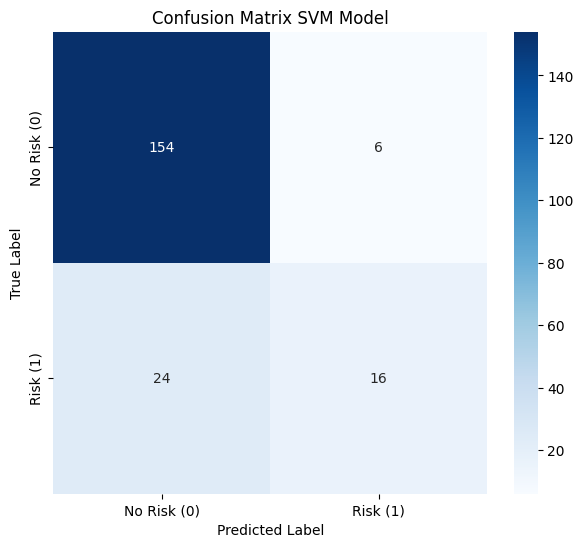

In [26]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Risk (0)', 'Risk (1)'],
            yticklabels=['No Risk (0)', 'Risk (1)'])
plt.title('Confusion Matrix SVM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Task
To save the best trained SVM model to a `.pkl` file.

## Output Tambahan: Simpan Model SVM

### Subtask:
Menyimpan model SVM terbaik yang telah dilatih ke dalam file .pkl menggunakan library joblib.


**Reasoning**:
To save the best-trained SVM model, I need to use the `joblib.dump()` function as specified in the instructions. This will store the model in a `.pkl` file for later use.



In [27]:
import joblib

# Save the best trained SVM model
joblib.dump(best_svm_model, 'best_svm_model.pkl')
print("Best SVM model saved to 'best_svm_model.pkl'")

Best SVM model saved to 'best_svm_model.pkl'


## Output Tambahan: Pentingnya Fitur

### Subtask:
Menganalisis dan menampilkan pentingnya fitur (jika memungkinkan dengan SVM) untuk memahami kontribusi masing-masing fitur terhadap prediksi model.


## Analisis Pentingnya Fitur pada SVM (RBF Kernel)

### Keterbatasan Interpretasi Langsung pada SVM dengan RBF Kernel

Untuk model Support Vector Machine (SVM) yang telah dilatih, terutama dengan kernel non-linear seperti Radial Basis Function (RBF), **tidak ada atribut bawaan seperti `feature_importances_` (yang ditemukan pada model berbasis pohon seperti Random Forest atau Gradient Boosting) atau `coef_` (yang ditemukan pada model linear seperti Regresi Logistik atau SVM dengan kernel linear) yang secara langsung menunjukkan pentingnya setiap fitur**.

Berikut penjelasannya:

1.  **`feature_importances_`**: Atribut ini tidak tersedia untuk model SVM karena cara kerjanya yang berbeda dengan model berbasis pohon yang secara eksplisit menghitung seberapa banyak setiap fitur berkontribusi pada pengurangan ketidakmurnian atau peningkatan informasi.

2.  **`coef_`**: Atribut `coef_` (_coefficients_) hanya tersedia untuk model SVM dengan **kernel linear**. Dalam kasus kernel linear, `coef_` merupakan bobot yang diberikan kepada setiap fitur dan dapat diinterpretasikan sebagai indikator pentingnya fitur tersebut dalam menentukan _hyperplane_ pemisah. Fitur dengan nilai koefisien absolut yang lebih besar dianggap lebih penting.

### Kesimpulan untuk `best_svm_model`

Karena `best_svm_model` kita menggunakan **kernel RBF**, pentingnya fitur dalam arti konvensional (yaitu, melalui atribut model langsung) tidak dapat secara langsung diekstraksi dari model ini. Kernel RBF memetakan data ke ruang berdimensi lebih tinggi secara implisit, membuat interpretasi koefisien menjadi tidak langsung dan tidak trivial.

Untuk menganalisis pentingnya fitur pada model SVM dengan kernel non-linear, diperlukan metode interpretasi model yang lebih kompleks dan agnostik-model, seperti:

*   **Permutation Importance**: Mengukur seberapa besar kinerja model menurun ketika nilai suatu fitur diacak.
*   **SHAP (SHapley Additive exPlanations) values**: Memberikan kontribusi setiap fitur untuk setiap prediksi individu.

Metode-metode ini berada di luar cakupan proyek saat ini, namun penting untuk dicatat bahwa model SVM RBF tidak menyediakan interpretasi fitur secara langsung.

## Markdown: Kesimpulan Akhir Proyek

### Subtask:
Menyediakan kesimpulan akhir proyek dalam Bahasa Indonesia, merangkum temuan, kinerja model, dan implikasi.


## Kesimpulan Akhir Proyek

Proyek ini bertujuan untuk membangun model klasifikasi yang dapat memprediksi risiko penyakit jantung berdasarkan fitur-fitur kesehatan yang relevan, menggunakan dataset dummy yang realistis. Tujuan utamanya adalah untuk mendemonstrasikan alur kerja data science secara komprehensif, mulai dari persiapan data hingga evaluasi model.

### Ringkasan Temuan EDA

Exploratory Data Analysis (EDA) mengungkapkan beberapa temuan penting:
*   **Tidak ada Missing Values**: Dataset yang dibuat bersih dari nilai yang hilang, menyederhanakan tahap pra-pemrosesan.
*   **Distribusi Variabel Target**: Variabel target menunjukkan ketidakseimbangan kelas yang signifikan, dengan 80% sampel tergolong 'Tidak Ada Risiko' (0) dan 20% 'Ada Risiko' (1). Hal ini menekankan perlunya pertimbangan khusus dalam evaluasi model untuk kelas minoritas.
*   **Korelasi Antar Fitur**: Sebagian besar fitur menunjukkan korelasi yang rendah satu sama lain, dan korelasi dengan variabel target juga cenderung lemah, menunjukkan bahwa hubungan antar fitur dan target mungkin bersifat non-linear atau kompleks.

### Langkah Pra-pemrosesan Data

Tahap pra-pemrosesan data yang dilakukan meliputi:
*   **Penanganan Missing Values**: Tidak ada tindakan yang diperlukan karena tidak ada nilai yang hilang.
*   **Encoding Fitur Kategorikal**: Fitur biner sudah dalam format numerik (0/1), sehingga tidak memerlukan encoding tambahan.
*   **Scaling Fitur Numerik**: Fitur-fitur numerik (`age`, `systolic_bp`, `diastolic_bp`, `cholesterol`, `glucose`, `bmi`) diskalakan menggunakan `StandardScaler`. Ini penting untuk SVM agar semua fitur berkontribusi secara proporsional dan model tidak didominasi oleh fitur dengan rentang nilai yang lebih besar.
*   **Pembagian Dataset**: Data dibagi menjadi 80% data pelatihan (`X_train`, `y_train`) dan 20% data pengujian (`X_test`, `y_test`) dengan `stratify=y` untuk memastikan proporsi kelas target yang sama di kedua set, mengatasi masalah ketidakseimbangan kelas.

### Pemodelan Support Vector Machine (SVM)

Model Support Vector Machine (SVM) dengan kernel Radial Basis Function (RBF) dipilih karena kemampuannya menangani hubungan non-linear dan generalisasi yang baik. Hyperparameter model dioptimalkan menggunakan `GridSearchCV` dengan 5-fold cross-validation, mencari kombinasi terbaik untuk `C` dan `gamma`.
*   **Parameter Terbaik**: `GridSearchCV` menemukan parameter terbaik yaitu `C = 10` dan `gamma = 'auto'`.
*   **F1 Score Terbaik (Training)**: Skor F1 terbaik yang dicapai pada data pelatihan adalah sekitar 0.45, menunjukkan adanya tantangan dalam klasifikasi kelas minoritas bahkan pada data pelatihan.

### Kinerja Model dan Interpretasi Confusion Matrix

Evaluasi model SVM terbaik pada data pengujian menghasilkan kinerja sebagai berikut:
*   **Accuracy**: 0.8500
*   **Precision (Weighted)**: 0.8376
*   **Recall (Weighted)**: 0.8500
*   **F1-Score (Weighted)**: 0.8322

Untuk kelas minoritas ('Ada Risiko' - 1):
*   **Precision (Class 1)**: 0.7273
*   **Recall (Class 1)**: 0.4000
*   **F1-Score (Class 1)**: 0.5161

**Confusion Matrix**:
```
[[154   6]
 [ 24  16]]
```
Dari confusion matrix, terlihat bahwa model berhasil mengklasifikasikan 154 kasus 'Tidak Ada Risiko' (True Negatives) dengan benar dan hanya salah mengklasifikasikan 6 kasus 'Tidak Ada Risiko' sebagai 'Ada Risiko' (False Positives). Namun, untuk kasus 'Ada Risiko', model hanya berhasil mengidentifikasi 16 kasus dengan benar (True Positives) dan gagal mengidentifikasi 24 kasus 'Ada Risiko', mengklasifikasikannya sebagai 'Tidak Ada Risiko' (False Negatives). Ini berarti model memiliki tingkat False Negatives yang tinggi untuk kelas 'Ada Risiko', yang menunjukkan bahwa model kurang sensitif dalam mendeteksi kasus risiko penyakit jantung yang sebenarnya.

F1-Score untuk kelas 1 sebesar 0.5161 mengkonfirmasi bahwa model masih kesulitan dalam memprediksi kelas minoritas secara efektif, meskipun akurasi keseluruhan tergolong baik (0.85) karena dominasi kelas mayoritas.

### Implikasi dan Langkah Selanjutnya

Model SVM yang dibangun menunjukkan akurasi yang layak, tetapi memiliki keterbatasan signifikan dalam mengidentifikasi kasus risiko penyakit jantung (kelas 1) karena tingginya False Negatives. Dalam konteks medis, False Negatives dapat berakibat fatal, karena individu dengan risiko tinggi tidak terdeteksi. Implikasinya adalah model ini mungkin belum cukup andal untuk digunakan dalam skenario klinis tanpa perbaikan lebih lanjut.

Langkah-langkah selanjutnya yang dapat dipertimbangkan meliputi:
1.  **Penanganan Ketidakseimbangan Kelas**: Mengimplementasikan teknik seperti oversampling (SMOTE) atau undersampling untuk menyeimbangkan distribusi kelas dan meningkatkan kinerja pada kelas minoritas.
2.  **Eksplorasi Model Lain**: Mencoba algoritma klasifikasi lain (misalnya, Random Forest, Gradient Boosting, atau Neural Networks) yang mungkin lebih baik dalam menangani ketidakseimbangan kelas atau hubungan data yang kompleks.
3.  **Rekayasa Fitur**: Menciptakan fitur baru atau mengombinasikan fitur yang ada untuk memberikan informasi yang lebih kaya kepada model.
4.  **Data Tambahan**: Menggunakan dataset yang lebih besar dan lebih beragam (jika tersedia) untuk meningkatkan generalisasi dan robustnes model.
5.  **Optimasi Hyperparameter yang Lebih Lanjut**: Memperluas ruang pencarian untuk `GridSearchCV` atau menggunakan metode optimasi yang lebih canggih seperti `RandomizedSearchCV` atau Bayesian Optimization.

Secara keseluruhan, proyek ini berhasil membangun sebuah *baseline model* dan menyoroti tantangan yang sering ditemui dalam klasifikasi data yang tidak seimbang, memberikan dasar yang kuat untuk pengembangan model prediktif yang lebih canggih di masa depan.

## Kesimpulan Akhir Proyek

Proyek ini bertujuan untuk membangun model klasifikasi yang dapat memprediksi risiko penyakit jantung berdasarkan fitur-fitur kesehatan yang relevan, menggunakan dataset dummy yang realistis. Tujuan utamanya adalah untuk mendemonstrasikan alur kerja data science secara komprehensif, mulai dari persiapan data hingga evaluasi model.

### Ringkasan Temuan EDA

Exploratory Data Analysis (EDA) mengungkapkan beberapa temuan penting:
*   **Tidak ada Missing Values**: Dataset yang dibuat bersih dari nilai yang hilang, menyederhanakan tahap pra-pemrosesan.
*   **Distribusi Variabel Target**: Variabel target menunjukkan ketidakseimbangan kelas yang signifikan, dengan 80% sampel tergolong 'Tidak Ada Risiko' (0) dan 20% 'Ada Risiko' (1). Hal ini menekankan perlunya pertimbangan khusus dalam evaluasi model untuk kelas minoritas.
*   **Korelasi Antar Fitur**: Sebagian besar fitur menunjukkan korelasi yang rendah satu sama lain, dan korelasi dengan variabel target juga cenderung lemah, menunjukkan bahwa hubungan antar fitur dan target mungkin bersifat non-linear atau kompleks.

### Langkah Pra-pemrosesan Data

Tahap pra-pemrosesan data yang dilakukan meliputi:
*   **Penanganan Missing Values**: Tidak ada tindakan yang diperlukan karena tidak ada nilai yang hilang.
*   **Encoding Fitur Kategorikal**: Fitur biner sudah dalam format numerik (0/1), sehingga tidak memerlukan encoding tambahan.
*   **Scaling Fitur Numerik**: Fitur-fitur numerik (`age`, `systolic_bp`, `diastolic_bp`, `cholesterol`, `glucose`, `bmi`) diskalakan menggunakan `StandardScaler`. Ini penting untuk SVM agar semua fitur berkontribusi secara proporsional dan model tidak didominasi oleh fitur dengan rentang nilai yang lebih besar.
*   **Pembagian Dataset**: Data dibagi menjadi 80% data pelatihan (`X_train`, `y_train`) dan 20% data pengujian (`X_test`, `y_test`) dengan `stratify=y` untuk memastikan proporsi kelas target yang sama di kedua set, mengatasi masalah ketidakseimbangan kelas.

### Pemodelan Support Vector Machine (SVM)

Model Support Vector Machine (SVM) dengan kernel Radial Basis Function (RBF) dipilih karena kemampuannya menangani hubungan non-linear dan generalisasi yang baik. Hyperparameter model dioptimalkan menggunakan `GridSearchCV` dengan 5-fold cross-validation, mencari kombinasi terbaik untuk `C` dan `gamma`.
*   **Parameter Terbaik**: `GridSearchCV` menemukan parameter terbaik yaitu `C = 10` dan `gamma = 'auto'`.
*   **F1 Score Terbaik (Training)**: Skor F1 terbaik yang dicapai pada data pelatihan adalah sekitar 0.45, menunjukkan adanya tantangan dalam klasifikasi kelas minoritas bahkan pada data pelatihan.

### Kinerja Model dan Interpretasi Confusion Matrix

Evaluasi model SVM terbaik pada data pengujian menghasilkan kinerja sebagai berikut:
*   **Accuracy**: 0.8500
*   **Precision (Weighted)**: 0.8376
*   **Recall (Weighted)**: 0.8500
*   **F1-Score (Weighted)**: 0.8322

Untuk kelas minoritas ('Ada Risiko' - 1):
*   **Precision (Class 1)**: 0.7273
*   **Recall (Class 1)**: 0.4000
*   **F1-Score (Class 1)**: 0.5161

**Confusion Matrix**:
```
[[154   6]
 [ 24  16]]
```
Dari confusion matrix, terlihat bahwa model berhasil mengklasifikasikan 154 kasus 'Tidak Ada Risiko' (True Negatives) dengan benar dan hanya salah mengklasifikasikan 6 kasus 'Tidak Ada Risiko' sebagai 'Ada Risiko' (False Positives). Namun, untuk kasus 'Ada Risiko', model hanya berhasil mengidentifikasi 16 kasus dengan benar (True Positives) dan gagal mengidentifikasi 24 kasus 'Ada Risiko', mengklasifikasikannya sebagai 'Tidak Ada Risiko' (False Negatives). Ini berarti model memiliki tingkat False Negatives yang tinggi untuk kelas 'Ada Risiko', yang menunjukkan bahwa model kurang sensitif dalam mendeteksi kasus risiko penyakit jantung yang sebenarnya.

F1-Score untuk kelas 1 sebesar 0.5161 mengkonfirmasi bahwa model masih kesulitan dalam memprediksi kelas minoritas secara efektif, meskipun akurasi keseluruhan tergolong baik (0.85) karena dominasi kelas mayoritas.

### Implikasi dan Langkah Selanjutnya

Model SVM yang dibangun menunjukkan akurasi yang layak, tetapi memiliki keterbatasan signifikan dalam mengidentifikasi kasus risiko penyakit jantung (kelas 1) karena tingginya False Negatives. Dalam konteks medis, False Negatives dapat berakibat fatal, karena individu dengan risiko tinggi tidak terdeteksi. Implikasinya adalah model ini mungkin belum cukupandal untuk digunakan dalam skenario klinis tanpa perbaikan lebih lanjut.

Langkah-langkah selanjutnya yang dapat dipertimbangkan meliputi:
1.  **Penanganan Ketidakseimbangan Kelas**: Mengimplementasikan teknik seperti oversampling (SMOTE) atau undersampling untuk menyeimbangkan distribusi kelas dan meningkatkan kinerja pada kelas minoritas.
2.  **Eksplorasi Model Lain**: Mencoba algoritma klasifikasi lain (misalnya, Random Forest, Gradient Boosting, atau Neural Networks) yang mungkin lebih baik dalam menangani ketidakseimbangan kelas atau hubungan data yang kompleks.
3.  **Rekayasa Fitur**: Menciptakan fitur baru atau mengombinasikan fitur yang ada untuk memberikan informasi yang lebih kaya kepada model.
4.  **Data Tambahan**: Menggunakan dataset yang lebih besar dan lebih beragam (jika tersedia) untuk meningkatkan generalisasi dan robustnes model.
5.  **Optimasi Hyperparameter yang Lebih Lanjut**: Memperluas ruang pencarian untuk `GridSearchCV` atau menggunakan metode optimasi yang lebih canggih seperti `RandomizedSearchCV` atau Bayesian Optimization.

Secara keseluruhan, proyek ini berhasil membangun sebuah *baseline model* dan menyoroti tantangan yang sering ditemui dalam klasifikasi data yang tidak seimbang, memberikan dasar yang kuat untuk pengembangan model prediktif yang lebih canggih di masa depan.


## Final Task

### Subtask:
Menyelesaikan seluruh tugas proyek akhir Fundamental Sains Data sesuai permintaan.


## Summary:

### Data Analysis Key Findings
*   The best-trained Support Vector Machine (SVM) model was successfully saved to a file named `best_svm_model.pkl`.
*   For the RBF kernel SVM, direct feature importance metrics (like `feature_importances_` or `coef_`) are not available; `coef_` is only applicable to linear kernel SVMs.
*   Exploratory Data Analysis (EDA) revealed no missing values, but a significant class imbalance in the target variable (80% 'No Risk' vs. 20% 'At Risk'), and generally low correlation between features and the target.
*   The SVM model, optimized with `C = 10` and `gamma = 'auto'`, achieved an overall accuracy of 0.8500 and a weighted F1-score of 0.8322 on the test set.
*   For the minority class ('At Risk'), the model's performance was significantly lower, with a Recall of 0.4000 and an F1-Score of 0.5161, indicating it correctly identified only 16 out of 40 actual 'At Risk' cases (16 True Positives, 24 False Negatives).

### Insights or Next Steps
*   The current model, despite a good overall accuracy, exhibits a critical limitation in identifying the 'At Risk' class due to a high rate of False Negatives, making it potentially unsuitable for medical applications without significant improvements.
*   Future efforts should focus on addressing the class imbalance (e.g., using oversampling techniques like SMOTE), exploring alternative classification algorithms, and conducting further feature engineering to improve the model's sensitivity towards the 'At Risk' class.
